In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("experiment2/postprocessing/exp2_combined_data.csv")

In [3]:

test = len(df) == 13

# nRF against extra tiers

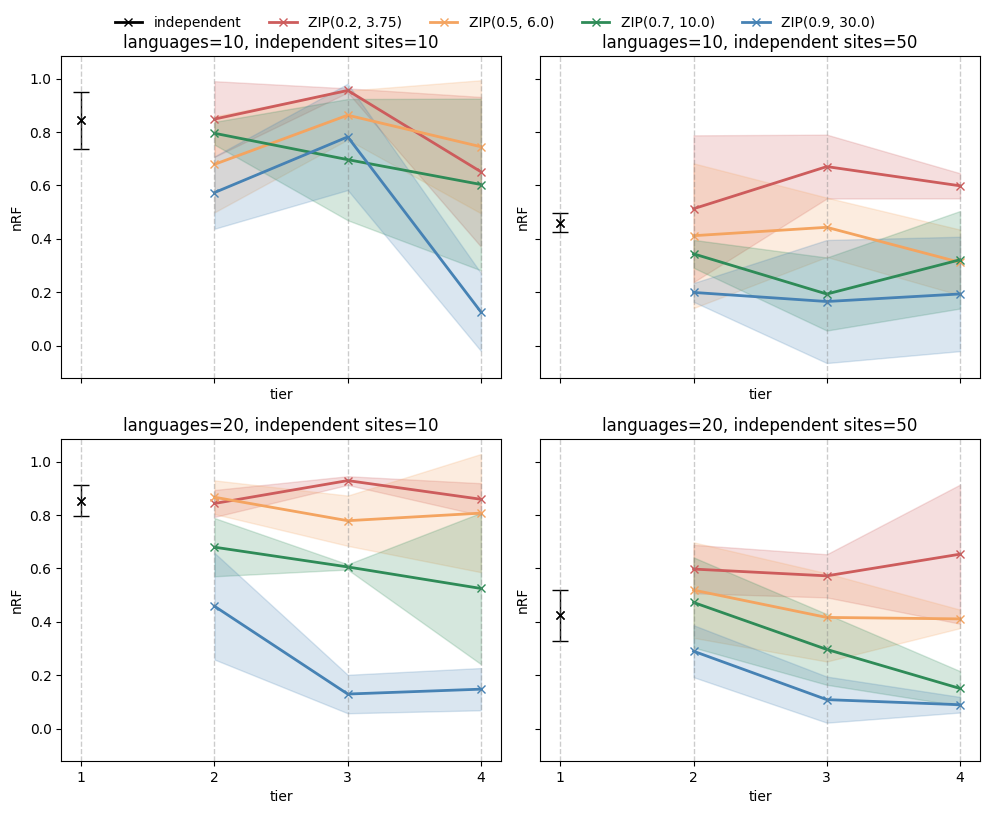

In [4]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]
for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        if test:
            ax = axes
        else:
            ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["meanNRF"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("nRF")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
if test:
    handles, labels = axes.get_legend_handles_labels()
else:
    handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

- Clearly more independent data is better from the plot (compare blue dots from left to right)
- But with more independent data adding tiers to the data is less useful (marginal improvement decreases?)
- In most cases, having more dependent data improves the model recovery
- Interestingly, generation needs to be extremely selective or extremely widespread - having ZIP(0.5, 6) actually nullifies the effect of more dependent tiers


make uninteresting plots
- plot amount of data that was created for each step

# Clade Recovery against extra tiers

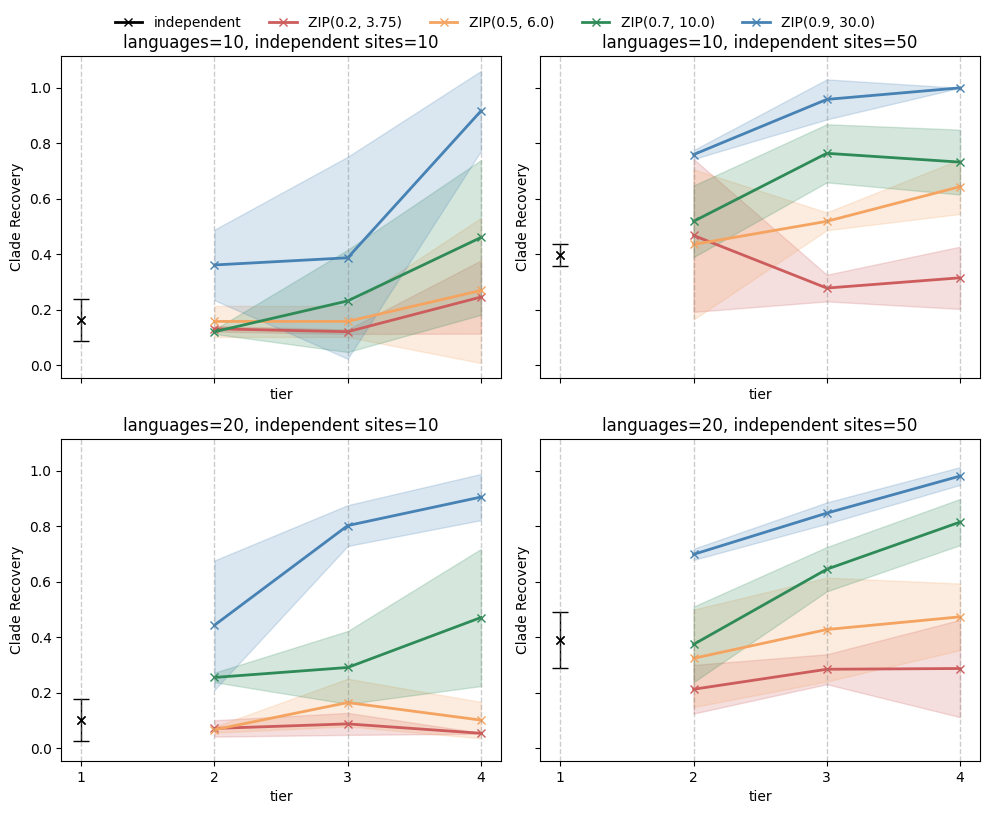

In [5]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["HighSupportCladesProp"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("Clade Recovery")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

# nRF against Clade Recovery (correlation perhaps?)

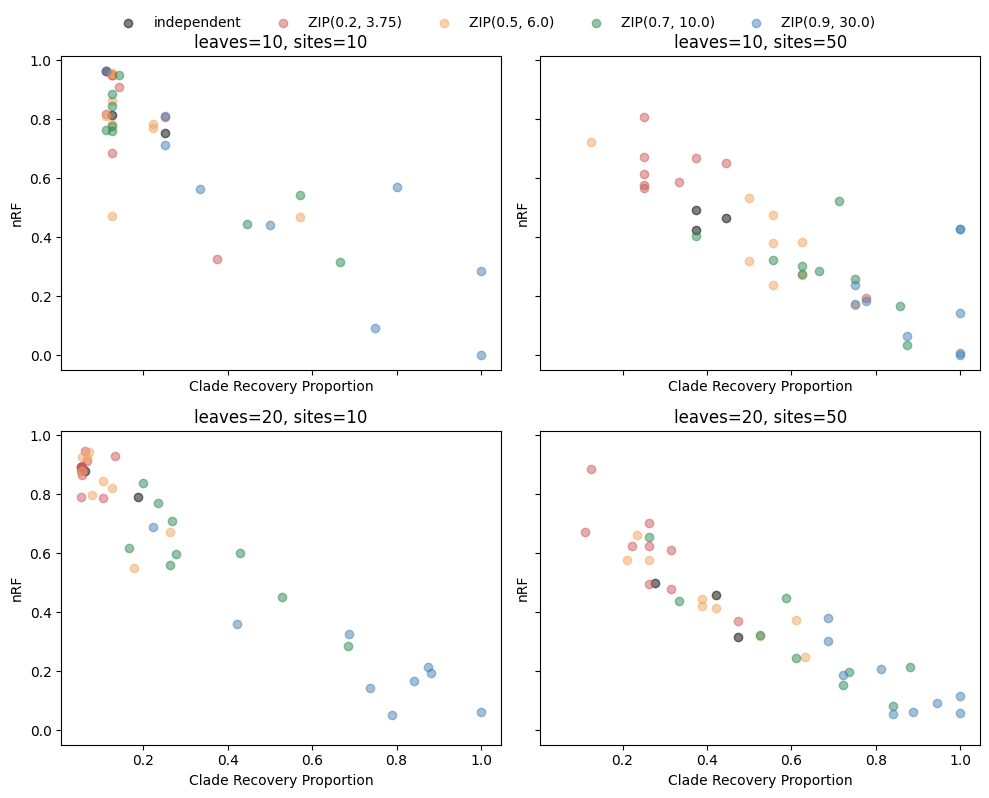

In [6]:
fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):

        ax = axes[i, j]

        d = df[
            (df["leaves"] == leaves_val) &
            (df["independent_sites"] == sites_val)
        ].copy()

        if d.empty:
            ax.set_visible(False)
            continue

        methods = d["ZIP"].unique()

        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]

            ax.scatter(
                dm["HighSupportCladesProp"],
                dm["meanNRF"],
                alpha=0.5,
                label=m,
                color=colors[k]
            )

        ax.set_title(f"leaves={leaves_val}, sites={sites_val}")
        ax.set_xlabel("Clade Recovery Proportion")
        ax.set_ylabel("nRF")


handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Tradeoff? not sure how to read this

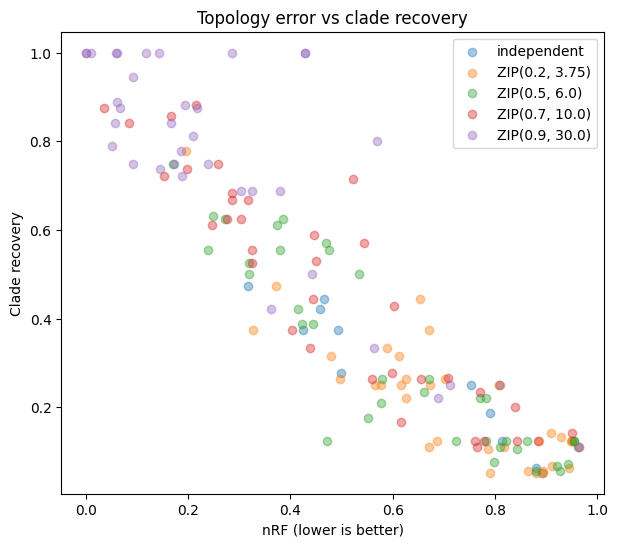

In [7]:
plt.figure(figsize=(7,6))

for m in df["ZIP"].unique():
    d = df[df["ZIP"] == m]

    plt.scatter(
        d["meanNRF"],
        d["HighSupportCladesProp"],
        alpha=0.4,
        label=m
    )

plt.xlabel("nRF (lower is better)")
plt.ylabel("Clade recovery")
plt.title("Topology error vs clade recovery")
plt.legend()
plt.show()

In [8]:
df.groupby(["leaves", "independent_sites", "tier"])[
    ["meanNRF", "HighSupportCladesProp"]
].corr()

meanNRF  \
leaves independent_sites tier                                   
10     10                1    meanNRF                1.000000   
                              HighSupportCladesProp -0.780903   
                         2    meanNRF                1.000000   
                              HighSupportCladesProp -0.630908   
                         3    meanNRF                1.000000   
                              HighSupportCladesProp -0.800141   
                         4    meanNRF                1.000000   
                              HighSupportCladesProp -0.902566   
       50                1    meanNRF                1.000000   
                              HighSupportCladesProp  0.128033   
                         2    meanNRF                1.000000   
                              HighSupportCladesProp -0.933443   
                         3    meanNRF                1.000000   
                              HighSupportCladesProp -0.832974   
                         4    meanNRF                1.000000   
                              HighSupportCladesProp -0.751371   
20     10                1    meanNRF                1.000000   
                              HighSupportCladesProp -0.998916   
                         2    meanNRF                1.000000   
                              HighSupportCladesProp -0.934362   
                         3    meanNRF                1.000000   
                              HighSupportCladesProp -0.958997   
                         4    meanNRF                1.000000   
                              HighSupportCladesProp -0.967861   
       50                1    meanNRF                1.000000   
                              HighSupportCladesProp -0.842624   
                         2    meanNRF                1.000000   
                              HighSupportCladesProp -0.909449   
                         3    meanNRF                1.000000   
                              HighSupportCladesProp -0.954253   
                         4    meanNRF                1.000000   
                              HighSupportCladesProp -0.944420   

                                                     HighSupportCladesProp  
leaves independent_sites tier                                               
10     10                1    meanNRF                            -0.780903  
                              HighSupportCladesProp               1.000000  
                         2    meanNRF                            -0.630908  
                              HighSupportCladesProp               1.000000  
                         3    meanNRF                            -0.800141  
                              HighSupportCladesProp               1.000000  
                         4    meanNRF                            -0.902566  
                              HighSupportCladesProp               1.000000  
       50                1    meanNRF                             0.128033  
                              HighSupportCladesProp               1.000000  
                         2    meanNRF                            -0.933443  
                              HighSupportCladesProp               1.000000  
                         3    meanNRF                            -0.832974  
                              HighSupportCladesProp               1.000000  
                         4    meanNRF                            -0.751371  
                              HighSupportCladesProp               1.000000  
20     10                1    meanNRF                            -0.998916  
                              HighSupportCladesProp               1.000000  
                         2    meanNRF                            -0.934362  
                              HighSupportCladesProp               1.000000  
                         3    meanNRF                            -0.958997  
                              HighSupportCladesProp               1.0000

In [9]:
df

,meanRF,varRF,meanNRF,varNRF,HighSupportCladesProp,likelihoodESS,priorESS,jointESS,tier,ZIP,leaves,independent_sites
0,13.474503,1.146489,0.962464,0.005849,0.111111,4790.834115,4130.648408,4220.462014,1,independent,10,10
1,12.727919,2.204297,0.909137,0.011246,0.142857,8056.032632,6145.932803,6276.851471,2,"ZIP(0.2, 3.75)",10,10
2,13.504944,1.088226,0.964639,0.005552,0.111111,6913.664398,4890.006244,5034.446294,3,"ZIP(0.2, 3.75)",10,10
3,11.438507,3.284246,0.817036,0.016756,0.111111,7398.454570,5734.322210,5967.205003,4,"ZIP(0.2, 3.75)",10,10
4,10.962782,2.817392,0.783056,0.014374,0.222222,9557.886679,7773.098287,8671.279917,2,"ZIP(0.5, 6.0)",10,10
...,...,...,...,...,...,...,...,...,...,...,...,...
151,8.390179,4.684188,0.246770,0.004052,0.611111,7229.603530,7231.093823,6781.742150,3,"ZIP(0.7, 10.0)",20,50
152,5.216309,3.704427,0.153421,0.003205,0.722222,6301.571323,7954.964125,6250.350729,4,"ZIP(0.7, 10.0)",20,50
153,10.311965,3.497333,0.303293,0.003025,0.687500,7644.731152,7118.713410,7408.533247,2,"ZIP(0.9, 30.0)",20,50
154,2.089323,1.968020,0.061451,0.001702,0.888889,4040.701093,9035.698002,4159.914246,3,"ZIP(0.9, 30.0)",20,50


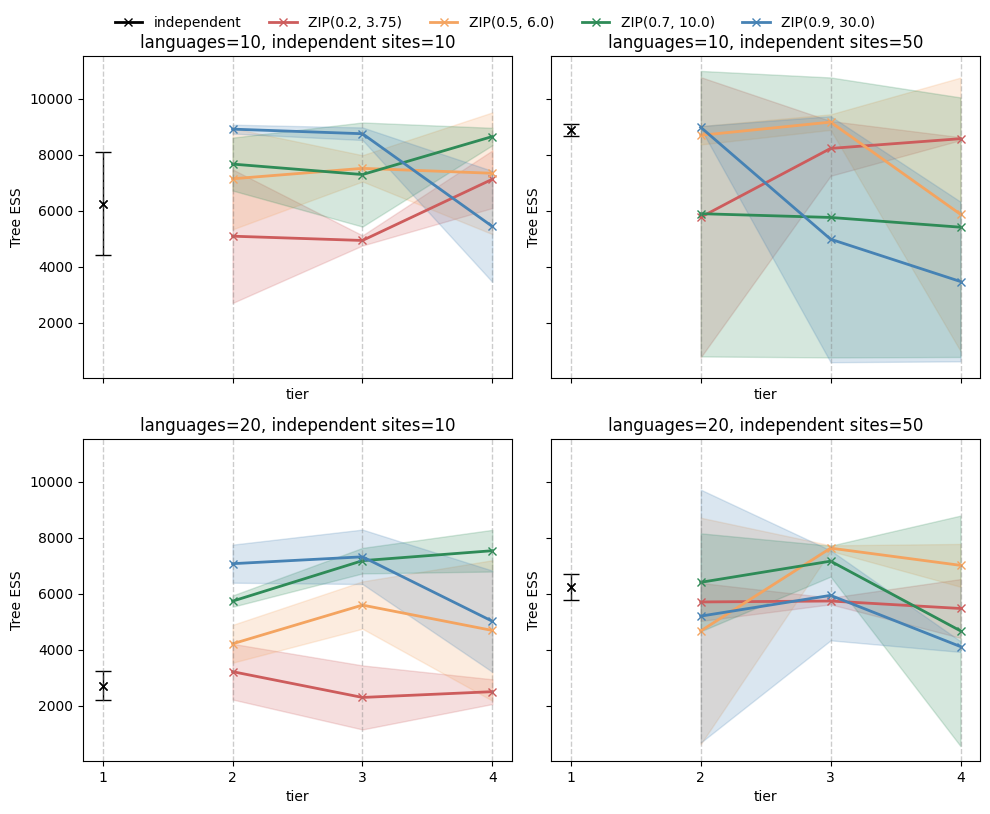

In [10]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["jointESS"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("Tree ESS")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

In [21]:
thing = pd.read_csv("experiment2/exp2_20_3_50/tier_sizes.csv")
thing['site_dep_param'] = 'ZIP' + thing['site_dep_param'].astype(str)
thing['current tier'] = [1, 2, 1, 2, 3, 1, 2, 3, 4]*4
thing['total tiers'] = thing['tier']
thing = thing.drop(columns=['tier'])
thing

,site_dep_param,size,current tier,total tiers
0,"ZIP(0.2, 3.75)",50,1,2
1,"ZIP(0.2, 3.75)",25,2,2
2,"ZIP(0.2, 3.75)",50,1,3
3,"ZIP(0.2, 3.75)",32,2,3
4,"ZIP(0.2, 3.75)",17,3,3
5,"ZIP(0.2, 3.75)",50,1,4
6,"ZIP(0.2, 3.75)",41,2,4
7,"ZIP(0.2, 3.75)",24,3,4
8,"ZIP(0.2, 3.75)",8,4,4
9,"ZIP(0.5, 6.0)",50,1,2


In [51]:
def generate_zip_variables(prob, mean, size):
            return (
                np.random.binomial(1, 1-prob, size)
                * np.random.poisson(mean, size)
            )

prob: 0.1, lambda: 11.11111111111111
prob: 0.2, lambda: 12.5
prob: 0.30000000000000004, lambda: 14.285714285714286
prob: 0.4, lambda: 16.666666666666668
prob: 0.5, lambda: 20.0
prob: 0.6, lambda: 25.0
prob: 0.7000000000000001, lambda: 33.33333333333334
prob: 0.8, lambda: 50.000000000000014
prob: 0.9, lambda: 100.00000000000003


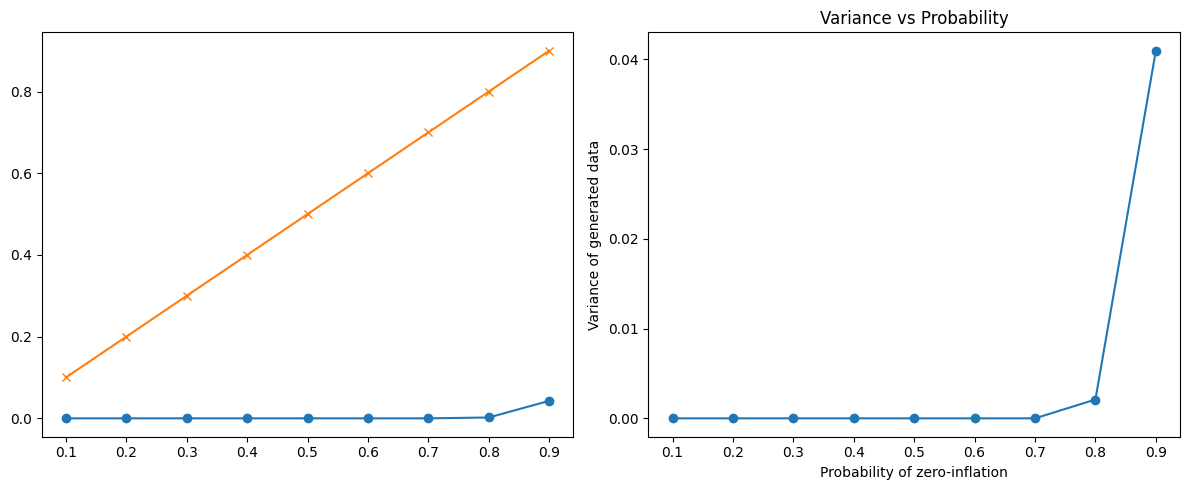

In [62]:
mu = 10
probs = np.linspace(0.1, 0.9, 9)
lambdas = mu/(1-probs)
size = 10000
data = np.zeros((9, size))
props = np.zeros((9, size))
for i in range(9):
    p = probs[i]
    l = lambdas[i]
    print(f"prob: {p}, lambda: {l}")
    generate_zip_variables(p, l, 10)
    for j in range(size):
        vals = generate_zip_variables(p, l, 30)
        data[i, j] = np.mean(vals)
        props[i, j] = np.mean(np.sum(vals) == 0)

# Plot mean and variance of each row as a function of probability
means = props.mean(axis=1)
variances = props.var(axis=1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(probs, means, marker='o')
plt.plot(probs, probs + (1-probs) * np.exp(-lambdas), marker='x', label='Theoretical mean')
plt.subplot(1, 2, 2)
plt.plot(probs, variances, marker='o')
plt.xlabel('Probability of zero-inflation')
plt.ylabel('Variance of generated data')
plt.title('Variance vs Probability')
plt.tight_layout()
plt.show()